## PART B — Multi-Layer ANN from Scratch
## Task 2: Define Deep ANN Architecture

In [1]:
import numpy as np

# ------------------------------
# Activation Functions
# ------------------------------

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ------------------------------
# ANN Architecture
# ------------------------------

# Example sizes
input_size = 3      # Number of input features
hidden1_size = 4    # Neurons in first hidden layer
hidden2_size = 3    # Neurons in second hidden layer
output_size = 1     # Binary output

# Initialize weights and biases
np.random.seed(42)  # For reproducibility

# Weights
W1 = np.random.randn(hidden1_size, input_size) * 0.01
b1 = np.zeros((hidden1_size, 1))

W2 = np.random.randn(hidden2_size, hidden1_size) * 0.01
b2 = np.zeros((hidden2_size, 1))

W3 = np.random.randn(output_size, hidden2_size) * 0.01
b3 = np.zeros((output_size, 1))

# Store weights in a dictionary for clarity
parameters = {
    "W1": W1, "b1": b1,
    "W2": W2, "b2": b2,
    "W3": W3, "b3": b3
}

# ------------------------------
# Forward Pass
# ------------------------------

def forward_pass(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    W3, b3 = params["W3"], params["b3"]
    
    # Layer 1
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    
    # Layer 2
    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)
    
    # Output Layer
    Z3 = W3 @ A2 + b3
    A3 = sigmoid(Z3)
    
    # Store intermediate values for backprop
    cache = {
        "Z1": Z1, "A1": A1,
        "Z2": Z2, "A2": A2,
        "Z3": Z3, "A3": A3
    }
    
    return A3, cache

# ------------------------------
# Test with a random input
# ------------------------------

X_test = np.random.randn(input_size, 1)  # single sample input
output, _ = forward_pass(X_test, parameters)

print("Input:\n", X_test)
print("Output (sigmoid):\n", output)


Input:
 [[ 0.37569802]
 [-0.60063869]
 [-0.29169375]]
Output (sigmoid):
 [[0.5]]


## Task 3: Forward propagation (All Layers)

In [2]:
import numpy as np

# ------------------------------
# Activation Functions
# ------------------------------

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ------------------------------
# Forward Propagation
# ------------------------------

def forward_propagation(X, parameters):
    """
    X: Input data, shape (input_size, number_of_examples)
    parameters: dictionary containing W1, b1, W2, b2, W3, b3
    """
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]
    
    # Layer 1: Linear -> ReLU
    Z1 = W1 @ X + b1       # Linear
    A1 = relu(Z1)          # Activation
    print("Shape of A1 (Hidden Layer 1):", A1.shape)
    
    # Layer 2: Linear -> ReLU
    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)
    print("Shape of A2 (Hidden Layer 2):", A2.shape)
    
    # Layer 3: Linear -> Sigmoid (Output)
    Z3 = W3 @ A2 + b3
    A3 = sigmoid(Z3)
    print("Shape of A3 (Output Layer):", A3.shape)
    
    # Cache intermediate values for backprop
    cache = {
        "X": X,
        "Z1": Z1, "A1": A1,
        "Z2": Z2, "A2": A2,
        "Z3": Z3, "A3": A3
    }
    
    return A3, cache

# ------------------------------
# Test Forward Propagation
# ------------------------------

# Random input: 3 features, 2 samples
X_test = np.random.randn(3, 2)

# Example parameters (from Task 2)
np.random.seed(42)
parameters = {
    "W1": np.random.randn(4, 3) * 0.01,
    "b1": np.zeros((4, 1)),
    "W2": np.random.randn(3, 4) * 0.01,
    "b2": np.zeros((3, 1)),
    "W3": np.random.randn(1, 3) * 0.01,
    "b3": np.zeros((1, 1))
}

output, cache = forward_propagation(X_test, parameters)

print("\nOutput of forward propagation:\n", output)


Shape of A1 (Hidden Layer 1): (4, 2)
Shape of A2 (Hidden Layer 2): (3, 2)
Shape of A3 (Output Layer): (1, 2)

Output of forward propagation:
 [[0.49999989 0.5       ]]


## Task 4: Backpropagation (Core Task)

In [3]:
import numpy as np

# ------------------------------
# Activation Derivatives
# ------------------------------

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid_derivative(A):
    # A is sigmoid(Z)
    return A * (1 - A)

# ------------------------------
# Backpropagation
# ------------------------------

def backpropagation(Y, parameters, cache):
    """
    Y: True labels, shape (1, number_of_samples)
    parameters: dictionary with W1,b1,... W3,b3
    cache: dictionary with X, Z1,A1,Z2,A2,Z3,A3
    """
    m = Y.shape[1]  # number of examples
    
    W1, W2, W3 = parameters["W1"], parameters["W2"], parameters["W3"]
    X = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    Z3, A3 = cache["Z3"], cache["A3"]
    
    # ------------------------------
    # Output Layer: Sigmoid + BCE
    # ------------------------------
    dZ3 = A3 - Y                     # derivative of BCE loss wrt Z3
    dW3 = (1/m) * dZ3 @ A2.T
    db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)
    
    # ------------------------------
    # Hidden Layer 2: ReLU
    # ------------------------------
    dA2 = W3.T @ dZ3                 # propagate gradient
    dZ2 = dA2 * relu_derivative(Z2) # element-wise
    dW2 = (1/m) * dZ2 @ A1.T
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # ------------------------------
    # Hidden Layer 1: ReLU
    # ------------------------------
    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1/m) * dZ1 @ X.T
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    # ------------------------------
    # Store gradients in a dictionary
    # ------------------------------
    grads = {
        "dW3": dW3, "db3": db3,
        "dW2": dW2, "db2": db2,
        "dW1": dW1, "db1": db1
    }
    
    return grads

# ------------------------------
# Test Backpropagation
# ------------------------------

# Example: 2 samples
Y_test = np.array([[1, 0]])  # true labels

# Assume forward pass already done:
output, cache = forward_propagation(X_test, parameters)

# Compute gradients
grads = backpropagation(Y_test, parameters, cache)

# Print gradient shapes for sanity check
for key, val in grads.items():
    print(f"{key} shape: {val.shape}")


Shape of A1 (Hidden Layer 1): (4, 2)
Shape of A2 (Hidden Layer 2): (3, 2)
Shape of A3 (Output Layer): (1, 2)
dW3 shape: (1, 3)
db3 shape: (1, 1)
dW2 shape: (3, 4)
db2 shape: (3, 1)
dW1 shape: (4, 3)
db1 shape: (4, 1)


## Task 5: Parameter Update

Epoch 500, Loss: 0.693147
Epoch 1000, Loss: 0.693147
Epoch 1500, Loss: 0.693147
Epoch 2000, Loss: 0.693147
Epoch 2500, Loss: 0.693147
Epoch 3000, Loss: 0.693147


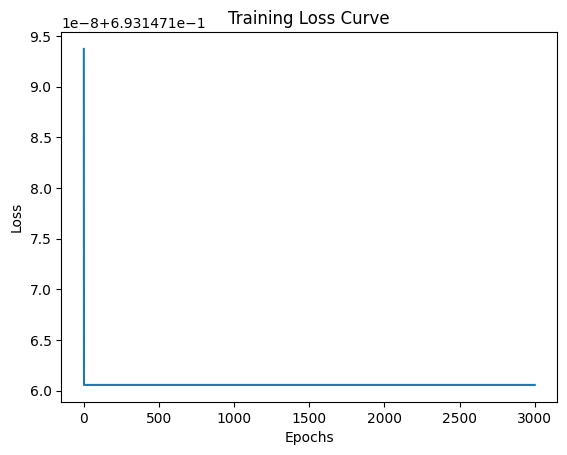

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Activation Functions
# ------------------------------

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu_derivative(z):
    return (z > 0).astype(float)

# ------------------------------
# Forward Propagation
# ------------------------------

def forward_propagation(X, parameters):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]
    
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)
    Z3 = W3 @ A2 + b3
    A3 = sigmoid(Z3)
    
    cache = {"X": X, "Z1": Z1, "A1": A1,
             "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    
    return A3, cache

# ------------------------------
# Backpropagation
# ------------------------------

def backpropagation(Y, parameters, cache):
    m = Y.shape[1]
    W1, W2, W3 = parameters["W1"], parameters["W2"], parameters["W3"]
    X = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    Z3, A3 = cache["Z3"], cache["A3"]
    
    dZ3 = A3 - Y
    dW3 = (1/m) * dZ3 @ A2.T
    db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)
    
    dA2 = W3.T @ dZ3
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (1/m) * dZ2 @ A1.T
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1/m) * dZ1 @ X.T
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW3": dW3, "db3": db3,
             "dW2": dW2, "db2": db2,
             "dW1": dW1, "db1": db1}
    
    return grads

# ------------------------------
# Loss Function (Binary Cross-Entropy)
# ------------------------------

def compute_loss(Y, A3):
    m = Y.shape[1]
    loss = - (1/m) * np.sum(Y * np.log(A3 + 1e-8) + (1 - Y) * np.log(1 - A3 + 1e-8))
    return loss

# ------------------------------
# Gradient Descent Parameter Update
# ------------------------------

def update_parameters(parameters, grads, learning_rate):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    parameters["W3"] -= learning_rate * grads["dW3"]
    parameters["b3"] -= learning_rate * grads["db3"]
    return parameters

# ------------------------------
# Training Loop
# ------------------------------

def train_ann(X, Y, parameters, epochs=5000, learning_rate=0.1, print_every=500):
    losses = []
    for i in range(1, epochs+1):
        # Forward pass
        A3, cache = forward_propagation(X, parameters)
        # Compute loss
        loss = compute_loss(Y, A3)
        losses.append(loss)
        # Backpropagation
        grads = backpropagation(Y, parameters, cache)
        # Parameter update
        parameters = update_parameters(parameters, grads, learning_rate)
        # Print loss every N epochs
        if i % print_every == 0:
            print(f"Epoch {i}, Loss: {loss:.6f}")
    # Plot Loss vs Epochs
    plt.plot(range(1, epochs+1), losses)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.show()
    return parameters, losses

# ------------------------------
# Example: Small Dataset (2 samples)
# ------------------------------

np.random.seed(42)
X_train = np.random.randn(3, 2)  # 3 features, 2 samples
Y_train = np.array([[1, 0]])     # binary labels

# Initialize parameters (same as before)
parameters = {
    "W1": np.random.randn(4, 3) * 0.01,
    "b1": np.zeros((4, 1)),
    "W2": np.random.randn(3, 4) * 0.01,
    "b2": np.zeros((3, 1)),
    "W3": np.random.randn(1, 3) * 0.01,
    "b3": np.zeros((1, 1))
}

# Train the network
parameters, losses = train_ann(X_train, Y_train, parameters, epochs=3000, learning_rate=0.1, print_every=500)


## PART C — Debugging & Deep Learning Intuition
## Task 6: Depth Experiment

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Activation Functions
# ------------------------------

def relu(z): 
    return np.maximum(0, z)

def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def relu_derivative(z): 
    return (z > 0).astype(float)

# ------------------------------
# Loss Function
# ------------------------------

def compute_loss(Y, A):
    m = Y.shape[1]
    return - (1/m) * np.sum(Y * np.log(A + 1e-8) + (1-Y) * np.log(1-A + 1e-8))

# ------------------------------
# Forward Propagation
# ------------------------------

# 1-hidden-layer ANN
def forward_1HL(X, parameters):
    Z1 = paramet


## Task 7: Vanishing Gradient Demonstration

Epoch 200, Loss: 0.673012
Epoch 400, Loss: 0.673012
Epoch 600, Loss: 0.673012
Epoch 800, Loss: 0.673012
Epoch 1000, Loss: 0.673012


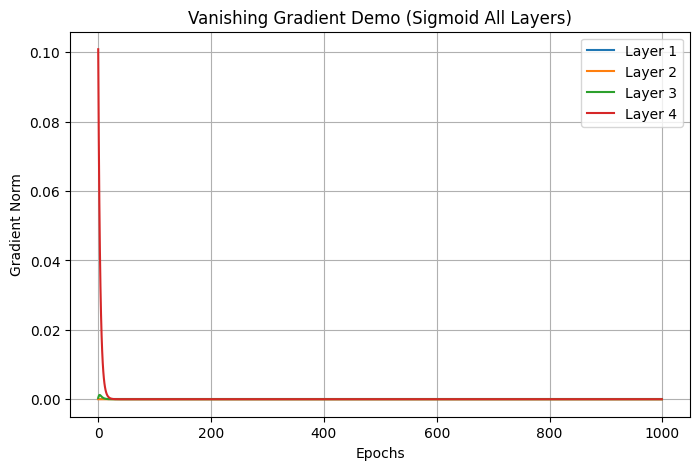

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# -----------------------------
# Loss Function
# -----------------------------
def compute_loss(Y, A):
    m = Y.shape[1]
    return - (1/m) * np.sum(Y*np.log(A+1e-8) + (1-Y)*np.log(1-A+1e-8))

# -----------------------------
# Forward Propagation
# -----------------------------
def forward_sigmoid(X, parameters):
    caches = {}
    caches["A0"] = X  # store input for backprop
    A = X
    L = len(parameters) // 2
    for l in range(1, L+1):
        Z = parameters[f"W{l}"] @ A + parameters[f"b{l}"]
        A = sigmoid(Z)
        caches[f"Z{l}"] = Z
        caches[f"A{l}"] = A
    return A, caches

# -----------------------------
# Backpropagation
# -----------------------------
def backprop_sigmoid(Y, parameters, caches):
    grads = {}
    L = len(parameters) // 2
    m = Y.shape[1]

    # Output layer
    A_L = caches[f"A{L}"]
    dZ = A_L - Y
    A_prev = caches[f"A{L-1}"]
    grads[f"dW{L}"] = (1/m) * dZ @ A_prev.T
    grads[f"db{L}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    
    dA_prev = dZ

    # Hidden layers
    for l in reversed(range(1, L)):
        W_next = parameters[f"W{l+1}"]
        dA = W_next.T @ dA_prev
        A_curr = caches[f"A{l}"]
        dZ = dA * sigmoid_derivative(A_curr)
        A_prev = caches[f"A{l-1}"]
        grads[f"dW{l}"] = (1/m) * dZ @ A_prev.T
        grads[f"db{l}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = dZ

    return grads

# -----------------------------
# Parameter Update
# -----------------------------
def update_parameters(parameters, grads, lr):
    for l in range(1, len(parameters)//2 + 1):
        parameters[f"W{l}"] -= lr * grads[f"dW{l}"]
        parameters[f"b{l}"] -= lr * grads[f"db{l}"]
    return parameters

# -----------------------------
# Training with Gradient Norm Tracking
# -----------------------------
def train_sigmoid_gradients(X, Y, parameters, epochs=1000, lr=0.5):
    grad_norms = {l: [] for l in range(1, len(parameters)//2 + 1)}
    losses = []

    for i in range(1, epochs+1):
        A, caches = forward_sigmoid(X, parameters)
        loss = compute_loss(Y, A)
        losses.append(loss)

        grads = backprop_sigmoid(Y, parameters, caches)

        # Track gradient norms per layer
        for l in range(1, len(parameters)//2 + 1):
            grad_norms[l].append(np.linalg.norm(grads[f"dW{l}"]))

        parameters = update_parameters(parameters, grads, lr)

        if i % 200 == 0:
            print(f"Epoch {i}, Loss: {loss:.6f}")

    return parameters, losses, grad_norms

# -----------------------------
# Example Dataset
# -----------------------------
np.random.seed(42)
X = np.random.randn(3, 5)
Y = np.array([[1,0,1,0,1]])

# 3 hidden layers + output
layer_sizes = [3, 4, 4, 4, 1]  # input + hidden1 + hidden2 + hidden3 + output
parameters = {}
for l in range(1, len(layer_sizes)):
    parameters[f"W{l}"] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.01
    parameters[f"b{l}"] = np.zeros((layer_sizes[l], 1))

# -----------------------------
# Train network
# -----------------------------
parameters, losses, grad_norms = train_sigmoid_gradients(X, Y, parameters, epochs=1000, lr=0.5)

# -----------------------------
# Plot Gradient Norms
# -----------------------------
plt.figure(figsize=(8,5))
for l in range(1, len(layer_sizes)):
    plt.plot(grad_norms[l], label=f"Layer {l}")
plt.xlabel("Epochs")
plt.ylabel("Gradient Norm")
plt.title("Vanishing Gradient Demo (Sigmoid All Layers)")
plt.legend()
plt.grid(True)
plt.show()
